In [34]:
import os
import pandas as pd

# Directory containing the .flow files
directory = 'CTU_13/4_rbot/'

# List to store individual dataframes
dataframes = []

# Loop through each file in the directory
for filename in os.listdir(directory):
    if filename.endswith('.flow'):
        # Read the file into a dataframe
        df = pd.read_csv(os.path.join(directory, filename))  # Adjust the reading method if necessary
        
        # Add a label column with the filename (without extension) as the label value
        #df['label'] = os.path.splitext(filename)[0]
        
        # Append the dataframe to the list
        dataframes.append(df)

# Concatenate all dataframes into a single dataframe
combined_4_df = pd.concat(dataframes, ignore_index=True)

combined_4_df.rename(columns={'Label': 'label'}, inplace=True)

# Remove rows where 'label' contains 'background'
combined_4_df = combined_4_df[~combined_4_df['label'].str.contains('Background', case=False, na=False)]

# Update the 'label' column: 'Botnet' -> 1, 'Normal' -> 0
combined_4_df['label'] = combined_4_df['label'].apply(lambda x: 1 if 'Botnet' in x else (0 if 'Normal' in x else x))

# Update the 'label' column: 'Botnet' -> 1, 'Normal' -> 0, 'Background' -> 0
#combined_4_df['label'] = combined_4_df['label'].apply(lambda x: 1 if 'Botnet' in x else (0 if 'Normal' in x or 'Background' in x else x))

# Optionally reset the index if needed
combined_4_df.reset_index(drop=True, inplace=True)

# Display the combined dataframe
print(combined_4_df)


       TotBytes  SrcBytes  DstBytes  SrcGap  DstGap  sMeanPktSz  dMeanPktSz  \
0         70674     25955     44719     0.0     0.0   75.670555  140.184952   
1           175       175         0     NaN     NaN  175.000000    0.000000   
2           166       166         0     NaN     NaN  166.000000    0.000000   
3           214       214         0     NaN     NaN  214.000000    0.000000   
4          1620       810       810     NaN     NaN   90.000000   90.000000   
...         ...       ...       ...     ...     ...         ...         ...   
27843       412       272       140     0.0     0.0   68.000000   70.000000   
27844       180        90        90     NaN     NaN   90.000000   90.000000   
27845       400        74       326     NaN     NaN   74.000000  326.000000   
27846       400        74       326     NaN     NaN   74.000000  326.000000   
27847       478       272       206     0.0     0.0   68.000000   68.666664   

       sMaxPktSz  dMaxPktSz  sMinPktSz  ...   PCRat

In [35]:
import os
import pandas as pd

# Directory containing the .flow files
directory = 'CTU_13/10_3_rbot/'

# List to store individual dataframes
dataframes = []

# Loop through each file in the directory
for filename in os.listdir(directory):
    if filename.endswith('.flow'):
        # Read the file into a dataframe
        df = pd.read_csv(os.path.join(directory, filename))  # Adjust the reading method if necessary
        
        # Add a label column with the filename (without extension) as the label value
        #df['label'] = os.path.splitext(filename)[0]
        
        # Append the dataframe to the list
        dataframes.append(df)

# Concatenate all dataframes into a single dataframe
combined_10_df = pd.concat(dataframes, ignore_index=True)

combined_10_df.rename(columns={'Label': 'label'}, inplace=True)

# Remove rows where 'label' contains 'background'
combined_10_df = combined_10_df[~combined_10_df['label'].str.contains('Background', case=False, na=False)]
combined_10_df = combined_10_df.fillna(method='ffill')  # Forward fill

# Update the 'label' column: 'Botnet' -> 1, 'Normal' -> 0
combined_10_df['label'] = combined_10_df['label'].apply(lambda x: 1 if 'Botnet' in x else (0 if 'Normal' in x else x))

# Update the 'label' column: 'Botnet' -> 1, 'Normal' -> 0, 'Background' -> 0
#combined_10_df['label'] = combined_10_df['label'].apply(lambda x: 1 if 'Botnet' in x else (0 if 'Normal' in x or 'Background' in x else x))

# Optionally reset the index if needed
combined_10_df.reset_index(drop=True, inplace=True)

# Display the combined dataframe
print(combined_10_df)


C:\Users\mjf\AppData\Local\Temp\ipykernel_15276\4115122841.py:29: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  combined_10_df = combined_10_df.fillna(method='ffill')  # Forward fill


        TotBytes  SrcBytes  DstBytes  SrcGap  DstGap  sMeanPktSz  dMeanPktSz  \
0         978731    245317    733414     0.0     0.0  177.508682  439.960419   
1            924       462       462     0.0     0.0   66.000000   66.000000   
2            924       462       462     0.0     0.0   66.000000   66.000000   
3            400        74       326     0.0     0.0   74.000000  326.000000   
4            400        74       326     0.0     0.0   74.000000  326.000000   
...          ...       ...       ...     ...     ...         ...         ...   
265903       280        81       199     0.0     0.0   81.000000  199.000000   
265904      1219       549       670     0.0     0.0  109.800003  134.000000   
265905       400        74       326     0.0     0.0   74.000000  326.000000   
265906       400        74       326     0.0     0.0   74.000000  326.000000   
265907       412       272       140     0.0     0.0   68.000000   70.000000   

        sMaxPktSz  dMaxPktSz  sMinPktSz

In [36]:
import os
import yaml
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
import re

def keep_features(df, features_to_keep):
    """
    Drop all columns from the DataFrame except for the specified features.
    
    Parameters:
    - df: pd.DataFrame, the input DataFrame
    - features_to_keep: list, list of column names to retain
    
    Returns:
    - pd.DataFrame with only the specified columns
    """
    # Ensure that the features_to_keep are in the DataFrame
    features_to_keep = [feature for feature in features_to_keep if feature in df.columns]
    
    # Return a DataFrame with only the specified features
    return df[features_to_keep]

# Function to preprocess each dataset
def preprocess_dataset(df):
    # Drop columns that contain only missing values
    df = df.dropna(axis=1, how='all')
    # Separate numeric and non-numeric columns
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    non_numeric_cols = df.select_dtypes(exclude=[np.number]).columns
    
    # Check if DataFrame has either numeric or non-numeric columns
    if not numeric_cols.empty or not non_numeric_cols.empty:
        # Handle missing values for numeric data
        if not numeric_cols.empty:
            imputer_numeric = SimpleImputer(strategy='mean')
            df_numeric = pd.DataFrame(imputer_numeric.fit_transform(df[numeric_cols]), columns=numeric_cols)
        else:
            df_numeric = pd.DataFrame()  # Empty DataFrame for numeric data if no numeric columns exist
        
        # Handle missing values for non-numeric data
        if not non_numeric_cols.empty:
            imputer_non_numeric = SimpleImputer(strategy='most_frequent')
            df_non_numeric = pd.DataFrame(imputer_non_numeric.fit_transform(df[non_numeric_cols]), columns=non_numeric_cols)
            # Convert non-numeric features to one-hot encoding
            encoder = OneHotEncoder(drop='first')
            encoded = encoder.fit_transform(df_non_numeric)
            encoded_df = pd.DataFrame(encoded.toarray(), columns=encoder.get_feature_names_out(non_numeric_cols))
        else:
            encoded_df = pd.DataFrame()  # Empty DataFrame for encoded non-numeric data if no non-numeric columns exist
        
        # Concatenate processed numeric and encoded non-numeric data
        df_preprocessed = pd.concat([df_numeric, encoded_df], axis=1)

        '''
        features = [
            'pRetran', 'Max', 'sMeanPktSz', 'SrcRetra', 'PCRatio',
            'SrcWin,SrcLoss', 'DstRate', 'SrcLoad', 'TcpOpt_MwsS  T', 'Load', 'DstLoad', 'TcpRtt', 'Flgs_ e g      ',
            'Flgs_ e d      ', 'Sum', 'AckDat', 'dTtl', 'Min', 'pLoss', 'DstLoss', 'State_S_',
            'Cause_Status', 'Loss', 'StdDev', 'Rate', 'SrcRate', 'IdleTime', 'Dur', 'SrcPkts', 'Flgs_ e s      ',
            'SrcGap', 'DstBytes', 'DstGap', 'sTtl', 'DstWin', 'TotPkts', 'DstPkts', 'Flgs_ e *      ', 'Mean',
            'SrcBytes', 'State__SA', 'TotBytes', 'Cause_Start', 'dMeanPktSz', 'DstRetra', 'SynAck'
        ]
        
        '''
        features = [
            'sTtl', 'AckDat', 'TcpRtt', 'SynAck', 'IdleTime', 'SrcBytes', 
            'DstWin', 'SrcWin', 'TcpOpt_MwsS  T', 'Min', 'Dur', 'pLoss',
            'Flgs_ e s      ', 'State_S_', 'TotPkts', 'DstPkts'
        ]
        
        # Drop all columns except the ones in features_to_keep
        df_preprocessed = keep_features(df_preprocessed, features)  

        # Scale features
        scaler = MinMaxScaler()
        df_scaled = pd.DataFrame(scaler.fit_transform(df_preprocessed), columns=df_preprocessed.columns)

        return df_scaled
    else:
        return pd.DataFrame()
    
# Step 1: Separate the label column
X_train = combined_4_df.drop(columns=['label'])
y_train = combined_4_df['label']

pre_df = preprocess_dataset(X_train)

pre_df['label'] = y_train

print(len(pre_df.columns))
pre_df['label']

# Step 2: Separate the label column
X_test = combined_10_df.drop(columns=['label'])
y_test = combined_10_df['label']

pre_test_df = preprocess_dataset(X_test)

pre_test_df['label'] = y_test

print(len(pre_test_df.columns))
pre_test_df['label']



17
17


0         0
1         0
2         0
3         0
4         0
         ..
265903    0
265904    0
265905    0
265906    0
265907    0
Name: label, Length: 265908, dtype: int64

In [37]:
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, recall_score, confusion_matrix, classification_report
import numpy as np

# Assuming `pre_df` is your training DataFrame and `pre_test_df` is your testing DataFrame, 'label' is your target column

# Step 1: Separate features (X) and target (y) for training
X_train = pre_df.drop(columns=['label'])  # Drop the label column to get the features
y_train = pre_df['label']  # Target variable

# Step 2: Separate features (X) and target (y) for validation and testing
X_test = pre_test_df.drop(columns=['label'])
y_test = pre_test_df['label']

# Step 3: Initialize the Random Forest Classifier
clf = RandomForestClassifier(n_estimators=10, random_state=42)

# Step 4: Perform cross-validation manually using X_test and y_test for validation
n_splits = 5  # Number of folds
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

train_accuracy_scores = []
train_f1_scores = []
train_recall_scores = []

test_accuracy_scores = []
test_f1_scores = []
test_recall_scores = []

for train_index, val_index in skf.split(X_train, y_train):
    X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

    # Train the model
    clf.fit(X_train_fold, y_train_fold)

    # Validate on the validation fold
    y_val_pred = clf.predict(X_val_fold)
    
    # Validate on the X_test dataset (which you're using as test in each fold)
    y_test_pred = clf.predict(X_test)

    # Evaluate metrics for the training fold
    train_accuracy_scores.append(accuracy_score(y_val_fold, y_val_pred))
    train_f1_scores.append(f1_score(y_val_fold, y_val_pred, average='macro'))
    train_recall_scores.append(recall_score(y_val_fold, y_val_pred, average='macro'))

    # Evaluate metrics for the X_test dataset
    test_accuracy_scores.append(accuracy_score(y_test, y_test_pred))
    test_f1_scores.append(f1_score(y_test, y_test_pred, average='macro'))
    test_recall_scores.append(recall_score(y_test, y_test_pred, average='macro'))

# Step 5: Print cross-validation results for training folds
print(f"Cross-Validation Training Accuracy: {np.mean(train_accuracy_scores):.4f} ± {np.std(train_accuracy_scores):.4f}")
print(f"Cross-Validation Training F1 Score: {np.mean(train_f1_scores):.4f} ± {np.std(train_f1_scores):.4f}")
print(f"Cross-Validation Training Recall: {np.mean(train_recall_scores):.4f} ± {np.std(train_recall_scores):.4f}")

# Step 6: Print cross-validation results for the X_test dataset
print(f"\nValidation on X_test - Accuracy: {np.mean(test_accuracy_scores):.4f} ± {np.std(test_accuracy_scores):.4f}")
print(f"Validation on X_test - F1 Score: {np.mean(test_f1_scores):.4f} ± {np.std(test_f1_scores):.4f}")
print(f"Validation on X_test - Recall: {np.mean(test_recall_scores):.4f} ± {np.std(test_recall_scores):.4f}")

# Step 7: Optionally, fit the model on the entire training dataset
clf.fit(X_train, y_train)

# Step 8: Feature Importances
importances = clf.feature_importances_
indices = importances.argsort()[::-1]  # Sort in descending order

# Step 9: Print top 10 feature importances
print("\nTop 10 Feature Importances:")
for i in range(min(10, len(indices))):  # Ensure there are at least 10 features
    print(f"Feature {X_train.columns[indices[i]]}: {importances[indices[i]]:.4f}")

# Step 10: Final prediction on the test set
y_pred = clf.predict(X_test)

# Confusion Matrix and Classification Report for the test set
print("\nConfusion Matrix on Final Test Set:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report on Final Test Set:")
print(classification_report(y_test, y_pred))


Cross-Validation Training Accuracy: 1.0000 ± 0.0001
Cross-Validation Training F1 Score: 0.9999 ± 0.0002
Cross-Validation Training Recall: 1.0000 ± 0.0000

Validation on X_test - Accuracy: 0.8221 ± 0.1783
Validation on X_test - F1 Score: 0.7929 ± 0.2143
Validation on X_test - Recall: 0.8224 ± 0.1780

Top 10 Feature Importances:
Feature sTtl: 0.3714
Feature DstPkts: 0.2378
Feature TotPkts: 0.2214
Feature State_S_: 0.0822
Feature pLoss: 0.0271
Feature Flgs_ e s      : 0.0235
Feature TcpRtt: 0.0087
Feature Min: 0.0068
Feature SrcBytes: 0.0060
Feature DstWin: 0.0046

Confusion Matrix on Final Test Set:
[[132691     43]
 [  3588 129586]]

Classification Report on Final Test Set:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99    132734
           1       1.00      0.97      0.99    133174

    accuracy                           0.99    265908
   macro avg       0.99      0.99      0.99    265908
weighted avg       0.99      0.99      0.99   

In [38]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import MiniBatchKMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, recall_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_validate
from scipy.stats import skew, kurtosis

def compute_incremental_stats(df, features):
    incremental_stats = pd.DataFrame(index=df.index)
    for feature in features:
        incremental_stats[f'{feature}_mean'] = df[feature].expanding().mean()
        incremental_stats[f'{feature}_median'] = df[feature].expanding().median()
        incremental_stats[f'{feature}_std'] = df[feature].expanding().std()
        #incremental_stats[f'{feature}_max'] = df[feature].expanding().max()
    return incremental_stats

def prepare_data(df, features):
    incremental_stats = compute_incremental_stats(df, features)
    incremental_stats.fillna(0, inplace=True)
    df_with_stats = pd.concat([df, incremental_stats], axis=1)
    return df_with_stats

def perform_clustering(X_scaled, n_clusters):
    kmeans = MiniBatchKMeans(n_clusters=n_clusters, random_state=42)
    clusters = kmeans.fit_predict(X_scaled)
    return kmeans, clusters

def train_cluster_classifiers(df_final, n_clusters):
    classifiers = {}
    results = {}
    
    for i in range(n_clusters):
        cluster_data = df_final[df_final['cluster'] == i]
        
        if len(cluster_data) == 0:
            print(f"Cluster {i} has no data. Skipping.")
            continue
        
        X_cluster = cluster_data.drop(columns=['label', 'cluster'])
        y_cluster = cluster_data['label']
        
        if len(X_cluster) < 5:
            print(f"Not enough data for cross-validation in cluster {i}.")
            continue
        
        clf = RandomForestClassifier(n_estimators=10, random_state=42)
        cv_results = cross_validate(clf, X_cluster, y_cluster, cv=5, scoring=['accuracy', 'f1_macro', 'recall_macro'], return_train_score=False)
        clf.fit(X_cluster, y_cluster)
        y_pred = clf.predict(X_cluster)
        cm = confusion_matrix(y_cluster, y_pred)
        
        classifiers[i] = clf
        results[i] = {
            'cv_accuracy': np.mean(cv_results['test_accuracy']),
            'cv_f1_score': np.mean(cv_results['test_f1_macro']),
            'cv_recall': np.mean(cv_results['test_recall_macro']),
            'confusion_matrix': cm,
            'classification_report': classification_report(y_cluster, y_pred)
        }
    
    return classifiers, results

def evaluate_on_test_set(df_test, df_test_final, test_clusters, classifiers):
    y_test_pred = np.zeros_like(df_test['label'], dtype=int)
    
    for idx, cluster in enumerate(test_clusters):
        clf = classifiers.get(cluster, None)
        if clf:
            sample_features = df_test_final.drop(columns=['label']).iloc[idx].to_frame().T
            y_test_pred[idx] = clf.predict(sample_features)[0]
    
    y_test = df_test['label']
    accuracy = accuracy_score(y_test, y_test_pred)
    f1 = f1_score(y_test, y_test_pred, average='macro')
    recall = recall_score(y_test, y_test_pred, average='macro')
    cm = confusion_matrix(y_test, y_test_pred)
    report = classification_report(y_test, y_test_pred)
    
    print("\nFinal Evaluation on Test Set:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"Recall: {recall:.4f}")
    print("\nConfusion Matrix:")
    print(cm)
    print("\nClassification Report:")
    print(report)

def main(pre_df, pre_test_df, feature_list, n_clusters):
    df = pre_df
    df_test = pre_test_df
    
    # Prepare training and test data
    df_with_stats = prepare_data(df, feature_list)
    df_test_with_stats = prepare_data(df_test, feature_list)
    
    # Standardize features
    incremental_feature_cols = [col for col in df_with_stats.columns if col.endswith(('mean', 'median', 'std'))]
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(df_with_stats[incremental_feature_cols])
    X_test_scaled = scaler.transform(df_test_with_stats[incremental_feature_cols])
    
    # Perform clustering
    kmeans, clusters = perform_clustering(X_scaled, n_clusters)
    df_with_stats['cluster'] = clusters
    
    # Train classifiers for each cluster
    df_final = df_with_stats.drop(columns=incremental_feature_cols)
    classifiers, results = train_cluster_classifiers(df_final, n_clusters)
    
    # Print results
    for i, result in results.items():
        print(f"\nCluster {i} - Random Forest Classifier Performance:")
        print(f"Cross-Validation Accuracy: {result['cv_accuracy']:.4f}")
        print(f"Cross-Validation F1 Score: {result['cv_f1_score']:.4f}")
        print(f"Cross-Validation Recall: {result['cv_recall']:.4f}")
        print("\nConfusion Matrix:")
        print(result['confusion_matrix'])
        print("\nClassification Report:")
        print(result['classification_report'])
    
    # Evaluate on the test set
    test_clusters = kmeans.predict(X_test_scaled)
    df_test_final = df_test_with_stats.drop(columns=incremental_feature_cols)
    evaluate_on_test_set(df_test, df_test_final, test_clusters, classifiers)

# Run the pipeline with the desired number of clusters
n_clusters = 2  # You can change this to any number of clusters
main(pre_df, pre_test_df, ['SynAck', 'TcpRtt', 'AckDat'], n_clusters)



Cluster 0 - Random Forest Classifier Performance:
Cross-Validation Accuracy: 0.9997
Cross-Validation F1 Score: 0.9994
Cross-Validation Recall: 0.9998

Confusion Matrix:
[[13225     0]
 [    0  2032]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     13225
           1       1.00      1.00      1.00      2032

    accuracy                           1.00     15257
   macro avg       1.00      1.00      1.00     15257
weighted avg       1.00      1.00      1.00     15257


Cluster 1 - Random Forest Classifier Performance:
Cross-Validation Accuracy: 0.9998
Cross-Validation F1 Score: 0.9986
Cross-Validation Recall: 0.9973

Confusion Matrix:
[[12043     0]
 [    0   548]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     12043
           1       1.00      1.00      1.00       548

    accuracy                           1.00     12591
   ma

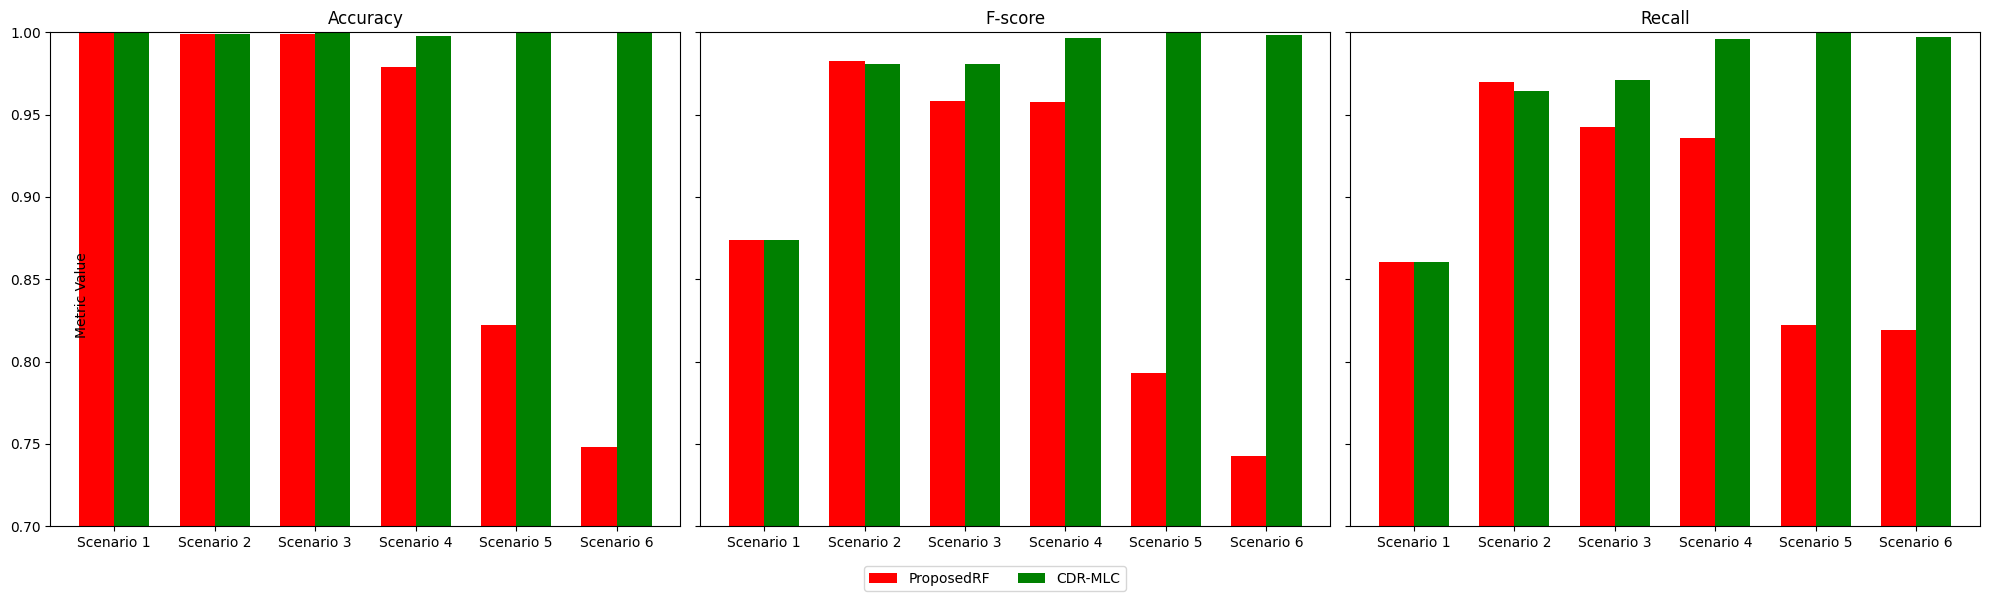

In [41]:
import matplotlib.pyplot as plt
import numpy as np

# Data for each scenario
scenarios = ['Scenario 1', 'Scenario 2', 'Scenario 3', 'Scenario 4', 'Scenario 5', 'Scenario 6']
accuracy = {
    'ProposedRF': [0.9993, 0.9992, 0.9989, 0.9790, 0.8221, 0.7481],
    'CDR-MLC': [0.9993, 0.9991, 0.9996, 0.9980, 0.9994, 0.9998]
}
f_score = {
    'ProposedRF': [0.8737, 0.9828, 0.9581, 0.9579, 0.7929, 0.7429],
    'CDR-MLC': [0.8737, 0.9806, 0.9809, 0.9964, 0.9994, 0.9986]
}
recall = {
    'ProposedRF': [0.8606, 0.9697, 0.9427, 0.9358, 0.8224, 0.8191],
    'CDR-MLC': [0.8606, 0.9643, 0.9712, 0.9957, 0.9994, 0.9973]
}
# Plotting all three metrics horizontally
fig, axs = plt.subplots(1, 3, figsize=(20, 6), sharey=True)  # 1 row, 3 columns layout

# Bar width for each plot
bar_width = 0.35
index = np.arange(len(scenarios))

# Plot for Accuracy
bar1 = axs[0].bar(index, accuracy['ProposedRF'], bar_width, label='ProposedRF', color='red')
bar2 = axs[0].bar(index + bar_width, accuracy['CDR-MLC'], bar_width, label='CDR-MLC', color='green')
axs[0].set_title('Accuracy')
axs[0].set_xticks(index + bar_width / 2)
axs[0].set_xticklabels(scenarios)
axs[0].set_ylim(0.6, 1)

# Plot for F-score
bar1 = axs[1].bar(index, f_score['ProposedRF'], bar_width, label='ProposedRF', color='red')
bar2 = axs[1].bar(index + bar_width, f_score['CDR-MLC'], bar_width, label='CDR-MLC', color='green')
axs[1].set_title('F-score')
axs[1].set_xticks(index + bar_width / 2)
axs[1].set_xticklabels(scenarios)
axs[1].set_ylim(0.6, 1)

# Plot for Recall
bar1 = axs[2].bar(index, recall['ProposedRF'], bar_width, label='ProposedRF', color='red')
bar2 = axs[2].bar(index + bar_width, recall['CDR-MLC'], bar_width, label='CDR-MLC', color='green')
axs[2].set_title('Recall')
axs[2].set_xticks(index + bar_width / 2)
axs[2].set_xticklabels(scenarios)
axs[2].set_ylim(0.7, 1)

# Set y-label for the entire figure
fig.text(0.04, 0.5, 'Metric Value', va='center', rotation='vertical')

# Adding a common legend at the bottom
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2)

plt.tight_layout(rect=[0, 0.05, 1, 1])  # Adjust layout to make space for the legend
plt.show()
